# Analysis of FPV scenarios by comparing model output

Author: Sofia Midauar


Date: February 2025

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from osgeo import ogr # conda install gdal
import glob2 as glob
import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

import matplotlib.dates as mdates

import seaborn as sns
import re
import calendar

## Define functions

In [2]:
def is_fpv(x, y, polys):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
    `x` and `y` are 2D arrays with x and y coordinates.
    `polys` must be an iterable of osgeo.ogr.Geometry objects from a shapefile.
    """
    def is_in_polys(x, y):
        point = ogr.Geometry(ogr.wkbPoint)
        point.AddPoint(x, y)
        for poly in polys:
            if point.Within(poly):
                return True
        return False
    is_in_polys = np.vectorize(is_in_polys)
    return is_in_polys(x, y)

In [3]:
def create_fpv_mask(xcenters, ycenters, fpv_shp_file):
    """Returns a boolean mask array representing the presence of FPV-covered grid points.
     `xcenters` and `ycenters` are 2D arrays with x and y cell center coordinates. They can be obtained from XZ and XZ coordinates of a trim-*.nc file.
     `fpv_shp_file` is a path to a shapefile.
    """
    ds = ogr.Open(fpv_shp_file)
    layer = ds.GetLayer(0)
    polys = []
    for i in range(layer.GetFeatureCount()):
        feature = layer.GetFeature(i)
        geom = feature.geometry().Clone()
        polys.append(geom)

    return is_fpv(xcenters, ycenters, polys)

In [4]:
def season_of_date(date_UTC):
    """Returns season for given datetime"""
    year = str(pd.to_datetime(date_UTC.strftime('%Y-%m-%d')).year)
    seasons = {'spring': pd.date_range(start= pd.to_datetime(year +'-03-21'), end=pd.to_datetime(year + '-06-20')),
               'summer': pd.date_range(start= pd.to_datetime(year + '-06-21'), end= pd.to_datetime(year + '-09-22')),
               'autumn': pd.date_range(start= pd.to_datetime(year + '-09-23'), end= pd.to_datetime(year + '-12-20')),
               'winter': pd.date_range(start= pd.to_datetime(year + '-12-21'), end= pd.to_datetime(year + '-03-20'))}
    if (pd.to_datetime(year +'-03-21') <= date_UTC <= pd.to_datetime(year + '-06-20')):
        return 'spring'
    elif (pd.to_datetime(year +'-06-21') <= date_UTC <= pd.to_datetime(year + '-09-22')):
        return 'summer'
    elif (pd.to_datetime(year +'-09-23') <= date_UTC <= pd.to_datetime(year + '-12-20')):
        return 'autumn'
    else:
        return 'winter'

## Folder location

In [5]:
# Folder path for model output FPV scenarios
path_output = '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios/'

# Folder path for shapefiles of scenarios analysed
path_shapes = '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/fpv_realistic/'

# Folder path for saving figures
path_figures = 'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/RTRM/'

## Read and process files

Note that constinuents (data variable R1) are indexed over M and N dimensions instead of MC and MC.

M, N are for **cell centers** (XZ, YZ).

MC, NC are for cell corners (XCOR, YCOR)

Thus, the coordinates to create the mask should be **XZ, YZ**.

In [9]:
# input trim files (model output)
trim_files = sorted(glob.glob(path_output + 'trim*.nc'))[:]
trim_files

['//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_DONUT_notransition.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov05_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_10x20.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov10_20x20.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov20_10x10.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov37nogap.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov41nogap.nc',
 '//luna/fst/LEC/Users/midauarg/delft_modelling/output_files/FPV_scenarios\\trim-FPV_real_cov43nogaps.nc',
 '//luna/fst/LEC/Users/midauarg/

In [7]:
trim_files[0][78:-3]

'FPV_real_DONUT_notransition'

In [10]:
# read output files and create array with only data that is under the FPV
temp_rho_dic = {}
temp_T_dic = {}
shapefile = '//luna/fst/LEC/Users/midauarg/arcgis_lakecab/lake_cab/lake_water_surface_right.shp' # shapefile for PEA

for run in range(0,len(trim_files)):
    name = trim_files[run][78:-3] # gets the working file name (scenario)
    ds = xr.open_dataset(trim_files[run])
    ds["DK_LYR"] = ds.S1 - ds.ZK_LYR # creates attribute with output depth
    ds["DK"] = ds.S1 - ds.ZK
    mask = create_fpv_mask(ds.XZ, ds.YZ, shapefile)
    ind_calc_PEA = np.argwhere(mask) # list of pairs (m,n) where mask is True
    temp = ds[['RHO', 'DK_LYR', 'DK']]
    temp_T = ds[['R1', 'DK_LYR', 'DK']]
    temp_rho_dic[name] = temp.copy()
    temp_T_dic[name] = temp_T.copy()

temp_rho_dic.keys()
temp_T_dic.keys()

dict_keys(['FPV_real_DONUT_notransition', 'FPV_real_cov05_10x10', 'FPV_real_cov10_10x10', 'FPV_real_cov10_10x20', 'FPV_real_cov10_20x20', 'FPV_real_cov20_10x10', 'FPV_real_cov37nogap', 'FPV_real_cov41nogap', 'FPV_real_cov43nogaps', 'FPV_real_nogaps', 'validation_fulldata_spatialmeteo'])

**Now we mask and redefine the data array for simplicity.**

This new data array can be easily indexed along time or depth (`KMAXOUT_RESTR`). Dimension `NM_MASKED` is dummy: it is a flattened dimension from M and N indices where FPV was present. This dimension should **only** be used to compute metrics, e.g., mean, along it.

NaN denote missing values (e.g., vertical layer below lake bottom or unresolved depth).

## Relative Thermal Resistance to Mixing - RTRM

In [9]:
# UNESCO formulation to estimate density: rho = rho0 + As + Bs^(1.5) + (Cs)²
WT = 4 # water temperature in °C
salinity = 0.5

rho0 = (999.842594 +(6.793952 * 0.01 * WT) - (9.095290 * 0.001 * (WT ** 2)) + (1.001685 * 0.0001 * (WT ** 3)) -
        (1.120083 * 0.000001 * (WT ** 4)) + (6.536332 * 0.000000001 * (WT ** 5)))
coef_A = (8.24493 * 0.1 - (4.0899 * 0.001 * (WT)) + (7.6438 * 0.00001 * (WT ** 2)) - (8.2467 * 0.0000001 * (WT ** 3)) +
          (5.3875 * 0.000000001 * (WT ** 4)))
coef_B = (((-5.72466) * 0.001) + (1.0227 * 0.0001 * (WT) - (1.6546 * 0.000001 * (WT ** 2))))
coef_C = (4.8314 * 0.0001)
rho_4degree = (rho0 + ((coef_A) * salinity) + ((coef_B) * (salinity ** (3 / 2))) + ((coef_C) * (salinity ** 2)))

## now for 5°C
WT = 5 # water temperature in °C
rho0 = (999.842594 +(6.793952 * 0.01 * WT) - (9.095290 * 0.001 * (WT ** 2)) + (1.001685 * 0.0001 * (WT ** 3)) -
        (1.120083 * 0.000001 * (WT ** 4)) + (6.536332 * 0.000000001 * (WT ** 5)))
coef_A = (8.24493 * 0.1 - (4.0899 * 0.001 * (WT)) + (7.6438 * 0.00001 * (WT ** 2)) - (8.2467 * 0.0000001 * (WT ** 3)) +
          (5.3875 * 0.000000001 * (WT ** 4)))
coef_B = (((-5.72466) * 0.001) + (1.0227 * 0.0001 * (WT) - (1.6546 * 0.000001 * (WT ** 2))))
coef_C = (4.8314 * 0.0001)
rho_5degree = (rho0 + ((coef_A) * salinity) + ((coef_B) * (salinity ** (3 / 2))) + ((coef_C) * (salinity ** 2)))

## now calculates denominator for Relative Thermal Resistance to Mixing (RTRM)
denominator_RTRM = (rho_5degree - rho_4degree)
denominator_RTRM

-0.009901633734557436

### For all reservoir points

In [1]:
temp_rho_dic['FPV_real_cov41nogap']

NameError: name 'temp_rho_dic' is not defined

In [66]:
temp_rho = temp_rho_dic['FPV_real_cov41nogap'].copy()
g = 9.81

# prepare storage
n_time = temp_rho.sizes['time'] # gets number of timesteps
n_cells = len(ind_calc_PEA) # gets number of grid cells
therm_depth_results = np.full((n_time, n_cells), np.nan) # empty array with y as long as timesteps and x as grid cells

for i in range(0, n_time):
    temp_time = temp_rho.isel(time = i)
    current_time = temp_time.time.values
    
    for j, cell in enumerate(ind_calc_PEA):
        temp_cell = temp_time.isel(M=cell[0], N=cell[1])
        
        depth = temp_cell.DK_LYR.values
        max_depth = temp_cell.DK.values  # This might be a 1D array
        rho = temp_cell.RHO.values
        mask = (depth > 0) & (rho > 0)
        
        depth = depth[mask]
        rho = rho[mask]
        delta_depth = np.diff(depth, prepend = np.nan)  # emulate .diff() but keep length
        valid = ~np.isnan(delta_depth) # Create a mask to filter out NaN values in delta_depth
    
        numerator = np.diff(rho, prepend = np.nan) # negative values as upper layer has lower density
        RTRM = (numerator/denominator_RTRM)
        
        combined_RTRM = list(zip(max_depth,depth, RTRM))
        combined_RTRM_df = pd.DataFrame(combined_RTRM, columns = ['max_depth', 'depth', 'RTRM'])
        combined_RTRM_df.dropna(inplace = True)
        
        if (combined_RTRM_df["RTRM"].max() > 30): # gets thermocline depth only if stratified condition
            try:
                therm_depth = combined_RTRM_df.loc[combined_RTRM_df["RTRM"].idxmax()]["depth"]
            except:
                therm_depth = np.nan
        else:
            therm_depth = np.nan
    
        therm_depth_results[i, j] = therm_depth  # Ensure is a scalar

In [67]:
pd.DataFrame(therm_depth_results).to_csv('therm_depth_FPV_real_cov41nogap.csv')

# Import RTRM dfs and process it for the whole lake

In [116]:
therm_depth_csvs = sorted(glob.glob('therm_depth*.csv')) 
therm_depth_csvs

['therm_depth_FPV_real_DONUT_notransition.csv',
 'therm_depth_FPV_real_cov05_10x10.csv',
 'therm_depth_FPV_real_cov10_10x10.csv',
 'therm_depth_FPV_real_cov10_10x20.csv',
 'therm_depth_FPV_real_cov10_20x20.csv',
 'therm_depth_FPV_real_cov20_10x10.csv',
 'therm_depth_FPV_real_cov37nogap.csv',
 'therm_depth_FPV_real_cov41nogap.csv',
 'therm_depth_FPV_real_cov43nogaps.csv',
 'therm_depth_FPV_real_nogaps.csv',
 'therm_depth_validation_fulldata_spatialmeteo.csv']

In [117]:
therm_depth_csvs = sorted(glob.glob('therm_depth*.csv')) # list output PEA files
times = pd.DataFrame(temp_rho_dic['FPV_real_cov05_10x10'].time.values, columns = ['time'])

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', 
          '37% without gaps', '41% without gaps', '43% without gaps',
          '46% without gaps', 'No FPV']

for scen in range(0, len(therm_depth_csvs), 1):
    temp_therm_depth = pd.read_csv(therm_depth_csvs[scen]).iloc[:, 1:] # read csv
    name = labels[scen]
    
    temp_therm_depth[name] = temp_therm_depth.median(axis = 1, skipna=True)
    temp_therm_depth = temp_therm_depth[temp_therm_depth.columns[[-1]]]
    temp_therm_depth['time'] = times['time']
    
    if scen == 0:
        therm_depth_df = temp_therm_depth.copy()
    else:
        therm_depth_df = pd.merge(therm_depth_df, temp_therm_depth, on = 'time', how = "inner")
    
therm_depth_df.set_index('time', inplace = True)
therm_depth_df.head(2)

,41% FPV - 10% gaps 80x80m,43% FPV - 5% gaps 10x10m,41% FPV - 10% gaps 10x10m,41% FPV - 10% gaps 10x20m,41% FPV - 10% gaps 20x20m,37% FPV - 20% gaps 10x10m,37% without gaps,41% without gaps,43% without gaps,46% without gaps,No FPV
time,,,,,,,,,,,
2022-09-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='time'>

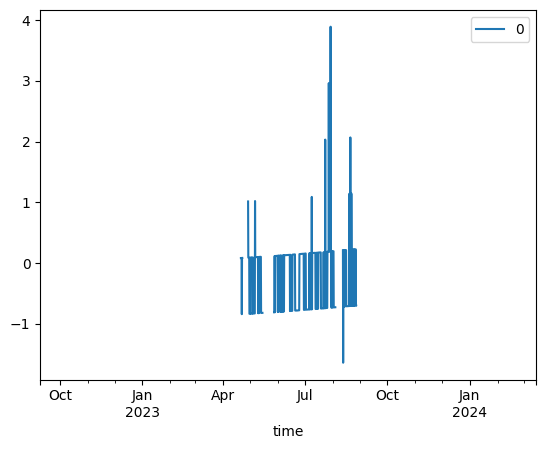

In [136]:
pd.DataFrame(therm_depth_df[scenarios[0]] - therm_depth_df[therm_depth_df.columns[-1]])

In [138]:
scenarios[0]

'41% FPV - 10% gaps 80x80m'

In [146]:
delta_therm_depth_df = therm_depth_df.copy()

scenarios = therm_depth_df.columns[:-1]

for col in range(len(therm_depth_df.columns)-1):
    if col == 0:
        delta_therm_depth_df = pd.DataFrame(therm_depth_df[scenarios[col]] - 
                                            therm_depth_df[therm_depth_df.columns[-1]])
        delta_therm_depth_df.columns = [scenarios[col]]
    else:
        delta_therm_depth_df[scenarios[col]] = (therm_depth_df[scenarios[col]] - 
                                                therm_depth_df[therm_depth_df.columns[-1]])

delta_therm_depth_df.head(2)

,41% FPV - 10% gaps 80x80m,43% FPV - 5% gaps 10x10m,41% FPV - 10% gaps 10x10m,41% FPV - 10% gaps 10x20m,41% FPV - 10% gaps 20x20m,37% FPV - 20% gaps 10x10m,37% without gaps,41% without gaps,43% without gaps,46% without gaps
time,,,,,,,,,,
2022-09-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-09-09 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [71]:
therm_depth_df.to_csv('therm_depth_df.csv')

## Prepare data for boxplots

In [15]:
## DATAFRAME FOR CREATING BOXPLOTS
scenarios = list(therm_depth_df.columns)

for scen in range(len(scenarios)):
    temporary = pd.DataFrame(therm_depth_df[scenarios[scen]].copy())

    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'Thermocline depth'}, inplace = True)
    temporary['scenario'] = scenarios[scen]
    # Join result to dataframe with control run output for comparison
    if (scen == 0):
        bp_therm_depth_comp = temporary.copy()
    else:
        bp_therm_depth_comp = pd.concat([bp_therm_depth_comp, temporary])

bp_therm_depth_comp['time'] = pd.to_datetime(bp_therm_depth_comp['time'])
bp_therm_depth_comp.set_index('time', inplace = True)
# # Creates columns with month
bp_therm_depth_comp['month'] = bp_therm_depth_comp.index.month
bp_therm_depth_comp['year'] = bp_therm_depth_comp.index.year
bp_therm_depth_comp['year'] = bp_therm_depth_comp['year'].apply(lambda x: str(x)[2:])
bp_therm_depth_comp['month_str'] = ((bp_therm_depth_comp['month'].apply(lambda x: calendar.month_abbr[x])) + 
                                    (bp_therm_depth_comp['year']))
bp_therm_depth_comp.reset_index(drop = False, inplace = True)
bp_therm_depth_comp['season'] = bp_therm_depth_comp['time'].apply(season_of_date)
# bp_PEA_comp.reset_index(drop = True, inplace = True)
bp_therm_depth_comp.head(2)

,time,Thermocline depth,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer


In [149]:
## DATAFRAME FOR CREATING BOXPLOTS
scenarios = list(delta_therm_depth_df.columns)

for scen in range(len(scenarios)):
    temporary = pd.DataFrame(delta_therm_depth_df[scenarios[scen]].copy())

    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'Thermocline depth'}, inplace = True)
    temporary['scenario'] = scenarios[scen]
    # Join result to dataframe with control run output for comparison
    if (scen == 0):
        bp_delta_therm_depth_comp = temporary.copy()
    else:
        bp_delta_therm_depth_comp = pd.concat([bp_delta_therm_depth_comp, temporary])

bp_delta_therm_depth_comp['time'] = pd.to_datetime(bp_delta_therm_depth_comp['time'])
bp_delta_therm_depth_comp.set_index('time', inplace = True)
# # Creates columns with month
bp_delta_therm_depth_comp['month'] = bp_delta_therm_depth_comp.index.month
bp_delta_therm_depth_comp['year'] = bp_delta_therm_depth_comp.index.year
bp_delta_therm_depth_comp['year'] = bp_delta_therm_depth_comp['year'].apply(lambda x: str(x)[2:])
bp_delta_therm_depth_comp['month_str'] = ((bp_delta_therm_depth_comp['month'].apply(lambda x: calendar.month_abbr[x])) +
                                          (bp_delta_therm_depth_comp['year']))
bp_delta_therm_depth_comp.reset_index(drop = False, inplace = True)
bp_delta_therm_depth_comp['season'] = bp_delta_therm_depth_comp['time'].apply(season_of_date)
# bp_PEA_comp.reset_index(drop = True, inplace = True)
bp_delta_therm_depth_comp.head(2)

,time,Thermocline depth,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer


# Plots - Thermocline depth 

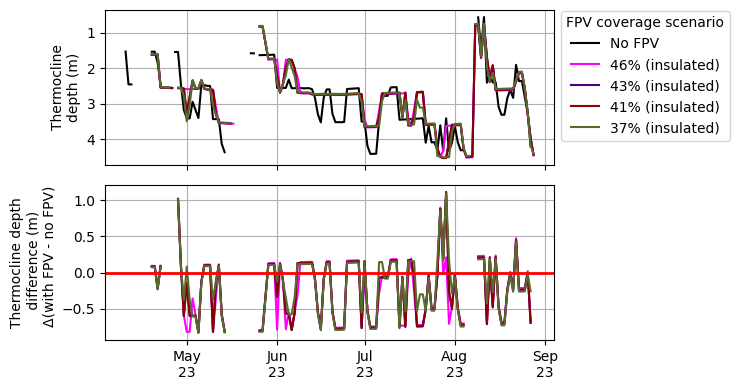

In [216]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7.5,4], sharex = True, sharey = False)
pal = sns.color_palette("tab20", 20)
colors_FPV01 = ['k', 'magenta', 'indigo', 'darkred', 'darkolivegreen']

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

scenarios_FPV01 = ['No FPV', '46% without gaps','43% without gaps',
                   '41% without gaps', '37% without gaps']

labels_FPV01 = ['No FPV', '46% (insulated)', '43% (insulated)',
                '41% (insulated)', '37% (insulated)']

therm_depth_df_plotFPV01 = therm_depth_df[scenarios_FPV01].copy().resample('D').mean()
for scen in range(len(therm_depth_df_plotFPV01.columns)):
    ax[0].plot(therm_depth_df_plotFPV01.index, therm_depth_df_plotFPV01[therm_depth_df_plotFPV01.columns[scen]], 
            color = colors_FPV01[scen], linestyle = 'solid', label = (labels_FPV01[scen]))

delta_therm_depth_df_plotFPV01 = delta_therm_depth_df[scenarios_FPV01[1:]].copy().resample('D').mean()
for scen in range(len(delta_therm_depth_df_plotFPV01.columns)):
    ax[1].plot(delta_therm_depth_df_plotFPV01.index, delta_therm_depth_df_plotFPV01[delta_therm_depth_df_plotFPV01.columns[scen]], 
            color = colors_FPV01[scen+1], linestyle = 'solid', label = (labels_FPV01[scen+1]))

ax[0].grid(True)
ax[1].grid(True)

ax[1].axhline(y = 0, color='r', linestyle='-', linewidth = 2)

ax[0].set_ylabel(u'Thermocline\ndepth (m)')
ax[1].set_ylabel(u'Thermocline depth\n difference (m)\n   Δ(with FPV - no FPV)')

ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))

myFmt = mdates.DateFormatter('%b\n%y')
ax[1].xaxis.set_major_formatter(myFmt)

plt.subplots_adjust(wspace = 0, hspace = 0)
ax[0].invert_yaxis()

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_oneplot_thermdepth_timeseries_delta.jpeg', dpi=300, bbox_inches='tight')

plt.show();

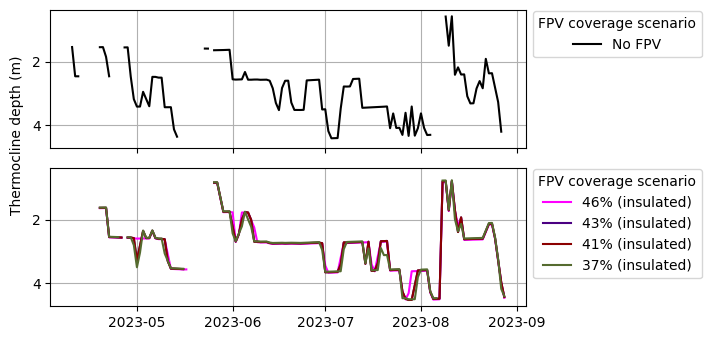

In [124]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,3.5], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)
colors_FPV01 = ['magenta', 'indigo', 'darkred', 'darkolivegreen']

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

scenarios_FPV01 = ['46% without gaps','43% without gaps',
                   '41% without gaps', '37% without gaps']

labels_FPV01 = ['46% (insulated)', '43% (insulated)',
                '41% (insulated)', '37% (insulated)']

therm_depth_noFPV = pd.DataFrame(therm_depth_df['No FPV']).copy().resample('D').mean()
ax[0].plot(therm_depth_noFPV.index, therm_depth_noFPV['No FPV'], 
            color = 'k', linestyle = 'solid', label = 'No FPV')

therm_depth_df_plotFPV01 = therm_depth_df[scenarios_FPV01].copy().resample('D').mean()
for scen in range(len(therm_depth_df_plotFPV01.columns)):
    ax[1].plot(therm_depth_df_plotFPV01.index, therm_depth_df_plotFPV01[therm_depth_df_plotFPV01.columns[scen]], 
            color = colors_FPV01[scen], linestyle = 'solid', label = (labels_FPV01[scen]))

ax[0].grid(True)
ax[1].grid(True)
ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[1].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))

# xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
# xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
# ax[1].set_xticklabels(xlabels_new)

fig.text(-0.010, 0.6, u'Thermocline depth (m)', 
         va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)
plt.gca().invert_yaxis()

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_underFPV_thermdepth_timeseries_noFPVincluded.jpeg', dpi=300, bbox_inches='tight')

plt.show();

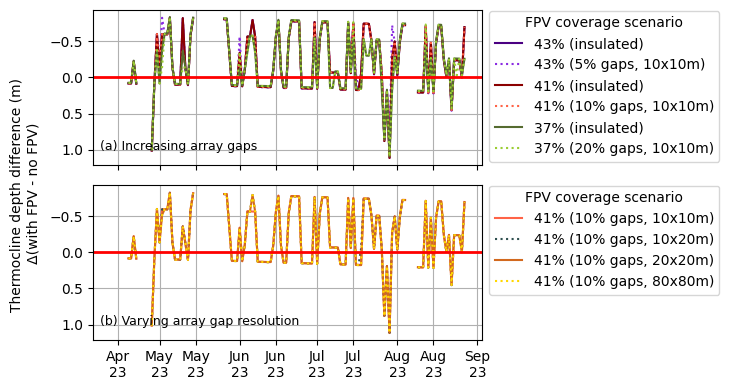

In [214]:
# Plot time series DELTA THERMOCLINE DEPTH
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,4], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)
linestyles = ['solid', 'dotted','solid', 'dotted','solid', 'dotted', 'solid']
colors_FPV02 = ['indigo', 'blueviolet', 'darkred', 'tomato', 'darkolivegreen', 'yellowgreen', 'k']
colors_FPV03 = ['tomato', 'darkslategray', 'chocolate', 'gold', 'k']

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

scenarios_FPV02 = ['43% without gaps','43% FPV - 5% gaps 10x10m', 
                   '41% without gaps','41% FPV - 10% gaps 10x10m', 
                   '37% without gaps', '37% FPV - 20% gaps 10x10m']

labels_FPV02 = ['43% (insulated)', '43% (5% gaps, 10x10m)', 
                '41% (insulated)', '41% (10% gaps, 10x10m)', 
                '37% (insulated)', '37% (20% gaps, 10x10m)']

scenarios_FPV03 = ['41% FPV - 10% gaps 10x10m','41% FPV - 10% gaps 10x20m', 
                   '41% FPV - 10% gaps 20x20m','41% FPV - 10% gaps 80x80m']

labels_FPV03 = ['41% (10% gaps, 10x10m)', '41% (10% gaps, 10x20m)', 
                '41% (10% gaps, 20x20m)', '41% (10% gaps, 80x80m)']

delta_therm_depth_df_plotFPV02 = delta_therm_depth_df[scenarios_FPV02].copy().resample('D').mean()
for scen in range(len(delta_therm_depth_df_plotFPV02.columns)):
    ax[0].plot(delta_therm_depth_df_plotFPV02.index, 
               delta_therm_depth_df_plotFPV02[delta_therm_depth_df_plotFPV02.columns[scen]], 
               color = colors_FPV02[scen], linestyle = linestyles[scen], label = (labels_FPV02[scen]))

ax[0].grid(True)
ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[0].text(19455, 1, '(a) Increasing array gaps', color = 'k', fontsize = 9)

delta_therm_depth_df_plotFPV03 = delta_therm_depth_df[scenarios_FPV03].copy().resample('D').mean()
for scen in range(len(delta_therm_depth_df_plotFPV03.columns)):
    ax[1].plot(delta_therm_depth_df_plotFPV03.index, 
               delta_therm_depth_df_plotFPV03[delta_therm_depth_df_plotFPV03.columns[scen]], 
               color = colors_FPV03[scen], linestyle = linestyles[scen], label = (labels_FPV03[scen]))

ax[0].axhline(y = 0, color='r', linestyle='-', linewidth = 2)
ax[1].axhline(y = 0, color='r', linestyle='-', linewidth = 2)

ax[1].grid(True)
ax[1].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[1].text(19455, 1, '(b) Varying array gap resolution', color = 'k', fontsize = 9)

myFmt = mdates.DateFormatter('%b\n%y')
ax[1].xaxis.set_major_formatter(myFmt)

fig.text(-0.035, 0.5, u'Thermocline depth difference (m)\n           Δ(with FPV - no FPV)', 
         va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)
plt.gca().invert_yaxis()

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV02_03_underFPV_thermdepth_timeseries_delta.jpeg', dpi=300, bbox_inches='tight')

plt.show();

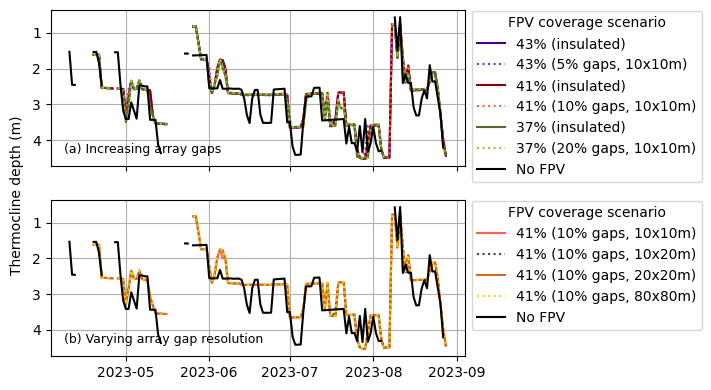

In [180]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,4], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)
linestyles = ['solid', 'dotted','solid', 'dotted','solid', 'dotted', 'solid']
colors_FPV02 = ['indigo', 'blueviolet', 'darkred', 'tomato', 'darkolivegreen', 'yellowgreen', 'k']
colors_FPV03 = ['tomato', 'darkslategray', 'chocolate', 'gold', 'k']

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

scenarios_FPV02 = ['43% without gaps','43% FPV - 5% gaps 10x10m', 
                   '41% without gaps','41% FPV - 10% gaps 10x10m', 
                   '37% without gaps', '37% FPV - 20% gaps 10x10m', 'No FPV']

labels_FPV02 = ['43% (insulated)', '43% (5% gaps, 10x10m)', 
                '41% (insulated)', '41% (10% gaps, 10x10m)', 
                '37% (insulated)', '37% (20% gaps, 10x10m)', 'No FPV']

scenarios_FPV03 = ['41% FPV - 10% gaps 10x10m','41% FPV - 10% gaps 10x20m', 
                   '41% FPV - 10% gaps 20x20m','41% FPV - 10% gaps 80x80m', 'No FPV']

labels_FPV03 = ['41% (10% gaps, 10x10m)', '41% (10% gaps, 10x20m)', 
                '41% (10% gaps, 20x20m)', '41% (10% gaps, 80x80m)', 'No FPV']

therm_depth_df_plotFPV02 = therm_depth_df[scenarios_FPV02].copy().resample('D').mean()
for scen in range(len(therm_depth_df_plotFPV02.columns)):
    ax[0].plot(therm_depth_df_plotFPV02.index, therm_depth_df_plotFPV02[therm_depth_df_plotFPV02.columns[scen]], 
               color = colors_FPV02[scen], linestyle = linestyles[scen], label = (labels_FPV02[scen]))

ax[0].grid(True)
ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[0].text(19455, 4.35, '(a) Increasing array gaps', color = 'k', fontsize = 9)

therm_depth_df_plotFPV03 = therm_depth_df[scenarios_FPV03].copy().resample('D').mean()
for scen in range(len(therm_depth_df_plotFPV03.columns)):
    ax[1].plot(therm_depth_df_plotFPV03.index, therm_depth_df_plotFPV03[therm_depth_df_plotFPV03.columns[scen]], 
               color = colors_FPV03[scen], linestyle = linestyles[scen], label = (labels_FPV03[scen]))

ax[1].grid(True)
ax[1].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[1].text(19455, 4.35, '(b) Varying array gap resolution', color = 'k', fontsize = 9)

# xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
# xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
# ax[1].set_xticklabels(xlabels_new)

fig.text(-0.010, 0.5, u'Thermocline depth (m)', 
         va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)
plt.gca().invert_yaxis()

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV02_03_underFPV_thermdepth_timeseries_noFPVincluded.jpeg', dpi=300, bbox_inches='tight')

plt.show();

In [350]:
bp_therm_depth_comp['scenario'].unique()

array(['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m',
       '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
       '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m',
       '37% without gaps', '41% without gaps', '43% without gaps',
       '46% without gaps', 'No FPV'], dtype=object)

In [206]:
bp_delta_therm_depth_comp

,time,Thermocline depth,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
2,2022-09-09 12:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
3,2022-09-09 18:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
4,2022-09-10 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
...,...,...,...,...,...,...,...
22125,2024-03-14 00:00:00,NaN,46% without gaps,3,24,Mar24,winter
22126,2024-03-14 06:00:00,NaN,46% without gaps,3,24,Mar24,winter
22127,2024-03-14 12:00:00,NaN,46% without gaps,3,24,Mar24,winter
22128,2024-03-14 18:00:00,NaN,46% without gaps,3,24,Mar24,winter


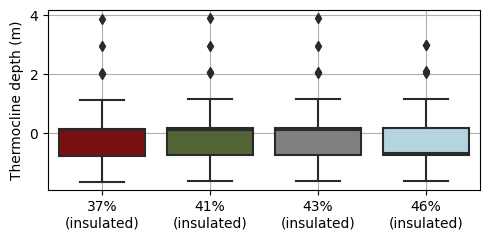

In [210]:
bp_delta_td_FPV01 = bp_delta_therm_depth_comp[(bp_delta_therm_depth_comp['scenario'] == '46% without gaps') |
                                              (bp_delta_therm_depth_comp['scenario'] == '43% without gaps') |
                                              (bp_delta_therm_depth_comp['scenario'] == '41% without gaps') |
                                              (bp_delta_therm_depth_comp['scenario'] == '37% without gaps')]

colors_FPV01 = ['darkred', 'darkolivegreen', 'gray', 'lightblue']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [5,2.5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_delta_td_FPV01,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax)

ax.grid(True)

ax.yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax.xaxis.set_label_text(u'')

# ax.invert_yaxis()

ax.set_xticks([0,1,2,3],
              ['37%\n(insulated)', '41%\n(insulated)', 
               '43%\n(insulated)', '46%\n(insulated)'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_scen_thermdepth_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

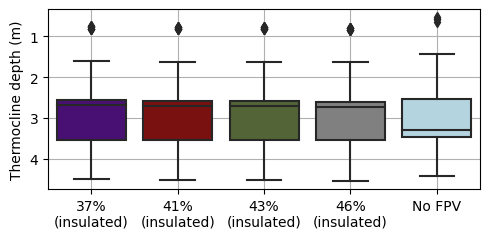

In [217]:
bp_td_FPV01 = bp_therm_depth_comp[(bp_therm_depth_comp['scenario'] == 'No FPV') |
                                  (bp_therm_depth_comp['scenario'] == '46% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '43% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '41% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '37% without gaps')]

colors_FPV01 = ['indigo', 'darkred', 'darkolivegreen', 'gray', 'lightblue']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [5,2.5], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV01,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax)

ax.grid(True)

ax.yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.invert_yaxis()

ax.set_xticks([0,1,2,3,4],
              ['37%\n(insulated)', '41%\n(insulated)', 
               '43%\n(insulated)', '46%\n(insulated)', 'No FPV'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_scen_thermdepth_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

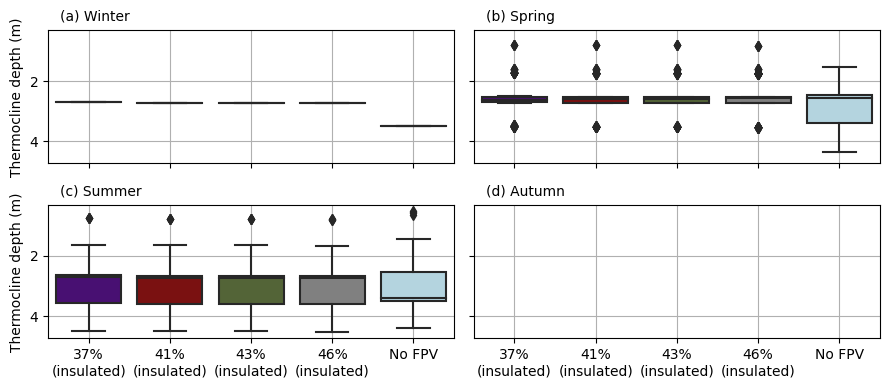

In [211]:
subset_winter = bp_therm_depth_comp[(bp_therm_depth_comp['season'] == 'winter')]
subset_spring = bp_therm_depth_comp[(bp_therm_depth_comp['season'] == 'spring')]
subset_summer = bp_therm_depth_comp[(bp_therm_depth_comp['season'] == 'summer')]
subset_autumn = bp_therm_depth_comp[(bp_therm_depth_comp['season'] == 'autumn')]

bp_td_FPV01_wi = subset_winter[(subset_winter['scenario'] == 'No FPV') |
                               (subset_winter['scenario'] == '46% without gaps') |
                               (subset_winter['scenario'] == '43% without gaps') |
                               (subset_winter['scenario'] == '41% without gaps') |
                               (subset_winter['scenario'] == '37% without gaps')]

bp_td_FPV01_sp = subset_spring[(subset_spring['scenario'] == 'No FPV') |
                               (subset_spring['scenario'] == '46% without gaps') |
                               (subset_spring['scenario'] == '43% without gaps') |
                               (subset_spring['scenario'] == '41% without gaps') |
                               (subset_spring['scenario'] == '37% without gaps')]

bp_td_FPV01_su = subset_summer[(subset_summer['scenario'] == 'No FPV') |
                               (subset_summer['scenario'] == '46% without gaps') |
                               (subset_summer['scenario'] == '43% without gaps') |
                               (subset_summer['scenario'] == '41% without gaps') |
                               (subset_summer['scenario'] == '37% without gaps')]

bp_td_FPV01_au = subset_autumn[(subset_autumn['scenario'] == 'No FPV') |
                               (subset_autumn['scenario'] == '46% without gaps') |
                               (subset_autumn['scenario'] == '43% without gaps') |
                               (subset_autumn['scenario'] == '41% without gaps') |
                               (subset_autumn['scenario'] == '37% without gaps')]

colors_FPV01 = ['indigo', 'darkred', 'darkolivegreen', 'gray', 'lightblue']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 2, figsize = [9,4], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV01_wi,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax[0,0])
ax[0,0].text(-0.35, 0, '(a) Winter', color = 'k', fontsize = 10)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV01_sp,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax[0,1])
ax[0,1].text(-0.35, 0, '(b) Spring', color = 'k', fontsize = 10)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV01_su,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax[1,0])
ax[1,0].text(-0.35, 0, '(c) Summer', color = 'k', fontsize = 10)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV01_au,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV01, ax = ax[1,1])
ax[1,1].text(-0.35, 0, '(d) Autumn', color = 'k', fontsize = 10)

ax[0,0].invert_yaxis()

ax[0,0].grid(True)
ax[0,1].grid(True)
ax[1,0].grid(True)
ax[1,1].grid(True)

ax[0,0].yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax[0,1].yaxis.set_label_text(u'')
ax[1,0].yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax[1,1].yaxis.set_label_text(u'')

ax[0,0].xaxis.set_label_text(u'')
ax[0,1].xaxis.set_label_text(u'')
ax[1,0].xaxis.set_label_text(u'')
ax[1,1].xaxis.set_label_text(u'')


ax[0,0].set_xticks([0,1,2,3,4],
                   ['37%\n(insulated)', '41%\n(insulated)', 
                    '43%\n(insulated)', '46%\n(insulated)', 'No FPV'],
                   fontsize = 10)

ax[0,1].set_xticks([0,1,2,3,4],
                   ['37%\n(insulated)', '41%\n(insulated)', 
                    '43%\n(insulated)', '46%\n(insulated)', 'No FPV'],
                   fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV01_scen_thermdepth_bp_depth_seasons.jpeg', dpi=600, bbox_inches='tight')

plt.show();

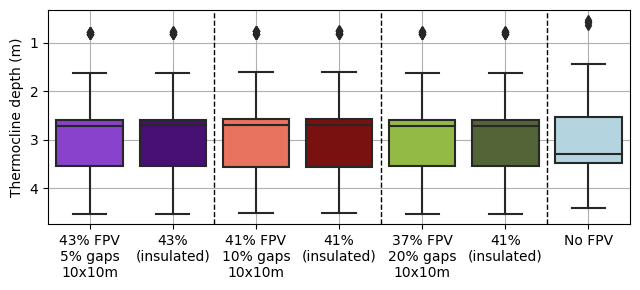

In [224]:
bp_td_FPV02 = bp_therm_depth_comp[(bp_therm_depth_comp['scenario'] == 'No FPV') |
                                  (bp_therm_depth_comp['scenario'] == '43% FPV - 5% gaps 10x10m') |
                                  (bp_therm_depth_comp['scenario'] == '43% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '41% FPV - 10% gaps 10x10m') |
                                  (bp_therm_depth_comp['scenario'] == '41% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '37% FPV - 20% gaps 10x10m') |
                                  (bp_therm_depth_comp['scenario'] == '37% without gaps')]

colors_FPV02 = ['blueviolet','indigo','tomato', 'darkred',  'yellowgreen', 'darkolivegreen', 'lightblue']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV02,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV02, ax = ax)

ax.grid(True)

ax.yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.axvline(1.5, color='k', linestyle='--', linewidth = 1)
ax.axvline(3.5, color='k', linestyle='--', linewidth = 1)
ax.axvline(5.5, color='k', linestyle='--', linewidth = 1)

ax.invert_yaxis()

ax.set_xticks([0,1,2,3,4,5,6],
              ['43% FPV\n5% gaps\n10x10m', '43%\n(insulated)',
               '41% FPV\n10% gaps\n10x10m', '41%\n(insulated)', 
               '37% FPV\n20% gaps\n10x10m', '41%\n(insulated)', 'No FPV'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV02_scen_thermdepth_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

In [398]:
bp_td_FPV03['scenario'].unique()

array(['41% FPV - 10% gaps 80x80m', '41% FPV - 10% gaps 10x10m',
       '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m',
       '41% without gaps', 'No FPV'], dtype=object)

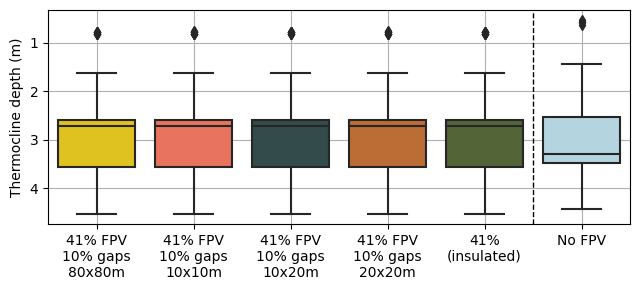

In [227]:
bp_td_FPV03 = bp_therm_depth_comp[(bp_therm_depth_comp['scenario'] == 'No FPV') |
                                  (bp_therm_depth_comp['scenario'] == '41% without gaps') |
                                  (bp_therm_depth_comp['scenario'] == '41% FPV - 10% gaps 80x80m') |
                                  (bp_therm_depth_comp['scenario'] == '41% FPV - 10% gaps 10x10m') |
                                  (bp_therm_depth_comp['scenario'] == '41% FPV - 10% gaps 10x20m') |
                                  (bp_therm_depth_comp['scenario'] == '41% FPV - 10% gaps 20x20m')]

colors_FPV03 = ['gold', 'tomato', 'darkslategray', 'chocolate', 'darkolivegreen', 'lightblue']

# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6.5,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "Thermocline depth", 
            data = bp_td_FPV03,
            width = 0.8, boxprops = {'zorder': 2}, palette = colors_FPV03, ax = ax)

ax.grid(True)

ax.yaxis.set_label_text(u'Thermocline depth (m)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.axvline(4.5, color='k', linestyle='--', linewidth = 1)

ax.invert_yaxis()

ax.set_xticks([0,1,2,3,4,5],
              ['41% FPV\n10% gaps\n80x80m', '41% FPV\n10% gaps\n10x10m',
               '41% FPV\n10% gaps\n10x20m', '41% FPV\n10% gaps\n20x20m',
               '41%\n(insulated)', 'No FPV'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV03_scen_thermdepth_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

In [90]:
therm_depth_df_plotFPV02.loc['2023-03-01 00:00:00':'2023-12-01 00:00:00']

,43% without gaps,43% FPV - 5% gaps 10x10m,41% without gaps,41% FPV - 10% gaps 10x10m,37% without gaps,37% FPV - 20% gaps 10x10m
time,,,,,,
2023-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2023-11-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-30 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-30 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
therm_depth_df_plotFPV02

,43% without gaps,43% FPV - 5% gaps 10x10m,41% without gaps,41% FPV - 10% gaps 10x10m,37% without gaps,37% FPV - 20% gaps 10x10m
time,,,,,,
2023-03-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-01 18:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-03-02 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
2023-11-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-30 06:00:00,NaN,NaN,NaN,NaN,NaN,NaN
2023-11-30 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN


### RTRM For one point in time

In [110]:
temp_rho.isel(time=1720)

<xarray.Dataset> Size: 636kB
Dimensions:        (KMAXOUT_RESTR: 16, M: 60, N: 50, K_LYR: 16, K_INTF: 17)
Coordinates:
    XZ             (M, N) float64 24kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    YZ             (M, N) float64 24kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
  * KMAXOUT_RESTR  (KMAXOUT_RESTR) int32 64B 0 1 2 3 4 5 6 ... 10 11 12 13 14 15
    time           datetime64[ns] 8B 2023-11-13
Dimensions without coordinates: M, N, K_LYR, K_INTF
Data variables:
    RHO            (KMAXOUT_RESTR, M, N) float32 192kB ...
    DK_LYR         (M, N, K_LYR) float32 192kB 13.87 12.48 ... 2.773 0.9244
    DK             (M, N, K_INTF) float32 204kB 14.79 12.94 ... 1.849 5.329e-15
Attributes:
    Conventions:  CF-1.6 SGRID-0.3
    institution:  Deltares
    references:   www.deltares.nl
    source:       Deltares, FLOW2D3D Version 6.04.02.142633, Nov 28 2023, 10:...
    history:      This file is created on 2025-03-11T11:04:10-0000, Delft3D
    LAYER_MODEL:  Z-MODEL

In [114]:
temp_rho = temp_rho_dic['FPV_real_nogaps'].copy()
temp_T = temp_T_dic['FPV_real_nogaps'].copy()
g = 9.81

# prepare storage
n_time = temp_rho.sizes['time'] # gets number of timesteps
n_cells = len(ind_calc_PEA) # gets number of grid cells
PEA_results = np.full((n_time, n_cells), np.nan) # creates an empty array with y as long as timesteps and x as grid cells

temp_time = temp_rho.isel(time=1740)
temp_time_T = temp_T.isel(time=1740)

current_time = temp_time.time.values

temp_cell = temp_time.isel(M=ind_calc_PEA[20][0], N=ind_calc_PEA[20][1])
temp_cell_T = temp_time_T.isel(M=ind_calc_PEA[20][0], N=ind_calc_PEA[20][1])

depth = temp_cell.DK_LYR.values
max_depth = temp_cell.DK.values  # This might be a 1D array
rho = temp_cell.RHO.values
water_temp = temp_cell_T.R1.values[0]

mask = (depth > 0) & (rho > 0)

depth = depth[mask]
rho = rho[mask]
water_temp = water_temp[mask]
delta_depth = np.diff(depth, prepend = np.nan)  # emulate .diff() but keep length
valid = ~np.isnan(delta_depth) # Create a mask to filter out NaN values in delta_depth

numerator = np.diff(rho, prepend = np.nan) # negative values as upper layer has lower density

denominator = denominator_RTRM # difference of water density at 4°C and 5°C

RTRM = (numerator/denominator)
RTRM

array([], dtype=float64)

In [115]:
combined_RTRM = list(zip(max_depth,depth, RTRM, water_temp))
combined_RTRM_df = pd.DataFrame(combined_RTRM, columns = ['max_depth', 'depth', 'RTRM', 'Temperature'])
combined_RTRM_df.dropna(inplace = True)
combined_RTRM_df

,max_depth,depth,RTRM,Temperature


In [34]:
bp_therm_depth_comp[(bp_therm_depth_comp['season'] == 'summer') |
                    (bp_therm_depth_comp['season'] == 'spring')]

,time,Thermocline depth,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
2,2022-09-09 12:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
3,2022-09-09 18:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
4,2022-09-10 00:00:00,NaN,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
...,...,...,...,...,...,...,...
23638,2023-09-21 00:00:00,NaN,No FPV,9,23,Sep23,summer
23639,2023-09-21 06:00:00,NaN,No FPV,9,23,Sep23,summer
23640,2023-09-21 12:00:00,NaN,No FPV,9,23,Sep23,summer
23641,2023-09-21 18:00:00,NaN,No FPV,9,23,Sep23,summer


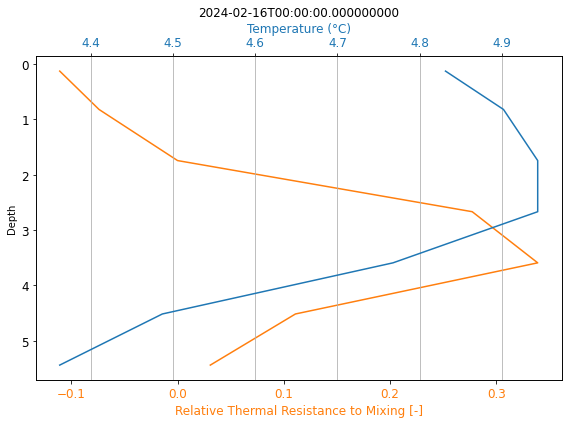

In [106]:
# Drop rows where RTRM is NaN to avoid plot issues
df_clean = combined_RTRM_df.dropna(subset=['RTRM'])

fig, ax1 = plt.subplots(figsize=(8, 6))

# Primary x-axis (bottom): RTRM vs depth
ax1.plot(df_clean['RTRM'], df_clean['depth'], color='tab:orange', label='RTRM')
ax1.set_xlabel('RTRM', color='tab:orange')
ax1.tick_params(axis='x', labelcolor='tab:orange')

# Invert y-axis to show depth increasing downward
ax1.invert_yaxis()
ax1.set_ylabel('Depth')
ax1.set_xlabel('Relative Thermal Resistance to Mixing [-]', fontsize = 12)
ax1.tick_params(axis='both', which='major', labelsize = 12)

# Secondary x-axis (top): Temperature vs depth
ax2 = ax1.twiny()
ax2.plot(df_clean['Temperature'], df_clean['depth'], color='tab:blue', label='Temperature')
ax2.set_xlabel('Temperature (°C)', color='tab:blue', fontsize = 12)
ax2.tick_params(axis='x', labelcolor='tab:blue')
ax2.tick_params(axis='both', which='major', labelsize = 12)

plt.title(current_time)
plt.grid(True)
plt.tight_layout()

plt.savefig(path_figures + 'one_example_RTRM_16Feb2024.jpeg', dpi=600, bbox_inches='tight')

plt.show()


# PEA

Only need to run this once with csv export - very inefficient making it impractical to run every time. 

Then code is set to import csv files back to make plots.

In [26]:
path_figures

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/figures_FPV/FPV_scenarios/'

In [75]:
### doing only one scenario
temp_rho = temp_rho_dic['FPV_real_DONUT_notransition'].copy()
g = 9.81

# prepare storage
n_time = temp_rho.sizes['time'] # gets number of timesteps
n_cells = len(ind_calc_PEA) # gets number of grid cells
PEA_results = np.full((n_time, n_cells), np.nan) # creates an empty array with y as long as timesteps and x as grid cells

for i in range(n_time):
    temp_time = temp_rho.isel(time=i)
    current_time = temp_time.time.values

    for j, cell in enumerate(ind_calc_PEA):
        temp_cell = temp_time.isel(M=cell[0], N=cell[1])
        
        depth = temp_cell.DK_LYR.values
        max_depth = temp_cell.DK.values  # This might be a 1D array
        rho = temp_cell.RHO.values
        
        # mask inactive or invalid values
        mask = (depth > 0) & (rho > 0)
        if np.count_nonzero(mask) <= 1: # if there's only one active layer, PEA is ZERO. if there's no active layer, PEA is NaN
            PEA_results[i, j] = 0 if np.count_nonzero(mask) == 1 else np.nan
            continue
        
        depth = depth[mask]
        rho = rho[mask]
        delta_depth = np.diff(depth, prepend = np.nan)  # emulate .diff() but keep length
        valid = ~np.isnan(delta_depth) # Create a mask to filter out NaN values in delta_depth
        
        mean_rho = np.sum(rho[valid] * delta_depth[valid]) / np.sum(delta_depth[valid])
        to_sum = (mean_rho - rho[valid]) * g * depth[valid] * delta_depth[valid]
        
        # Handle the case where max_depth is a 1D array, take the first value
        if np.ndim(max_depth) > 0:
            max_depth = max_depth[0]
        
        PEA = (1 / max_depth) * np.sum(to_sum)
        PEA_results[i, j] = PEA  # Ensure PEA is a scalar

PEA_results

array([[ 0.        ,  0.        ,  0.01294093, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.00152333, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        , -0.00194501, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.00056474, -0.00070545,  0.00836527, ...,  0.        ,
        -0.00016962, -0.00012271],
       [-0.00127919, -0.00127919, -0.00262519, ...,  0.        ,
        -0.00141093, -0.00140194],
       [-0.00132613, -0.00132612, -0.0027956 , ...,  0.        ,
        -0.00127019, -0.00127019]])

In [76]:
pd.DataFrame(PEA_results).to_csv('PEA_results_FPV_real_cov10_10x20.csv')

In [53]:
sorted(glob.glob('PEA*.csv'))

['PEA_df_01_coverages.csv',
 'PEA_results_FPV_real_cov05_10x10.csv',
 'PEA_results_FPV_real_cov10_10x10.csv',
 'PEA_results_FPV_real_cov20_10x10.csv',
 'PEA_results_FPV_real_cov37nogap.csv',
 'PEA_results_FPV_real_cov41nogap.csv',
 'PEA_results_FPV_real_cov43nogap.csv',
 'PEA_results_FPV_real_nogaps.csv',
 'PEA_results_noFPV.csv']

In [84]:
temp_time_T = ds.isel(time=1400)

temp_cell_T = temp_time_T.isel(M=ind_calc_PEA[20][0], N=ind_calc_PEA[20][1])

water_temp = temp_cell_T.R1.values[0]
depth = temp_cell_T.DK_LYR.values
max_depth = temp_cell_T.DK.values  # This might be a 1D array

mask = (depth > 0)

water_temp = water_temp[mask]

In [85]:
combined_WT = list(zip(max_depth,depth, water_temp))
combined_WT_df = pd.DataFrame(combined_WT, columns = ['max_depth', 'depth', 'Temperature'])
combined_WT_df = combined_WT_df[combined_WT_df['Temperature'] > 0]
combined_WT_df

,max_depth,depth,Temperature
1,6.515097,6.052909,25.221336
2,5.590723,5.128535,25.797167
3,4.666347,4.204160,26.972561
4,3.741972,3.279785,28.708586
5,2.817597,2.355410,31.443407
6,1.893222,1.431035,31.430702
7,0.968847,0.506660,31.406542


In [86]:
df = pd.merge(combined_WT_df, combined_RTRM_df, on = 'depth', how = 'left')
df.dropna(inplace = True)
df

,max_depth_x,depth,Temperature,max_depth_y,RTRM


# Import PEA dfs and process it for the whole lake

In [6]:
PEA_csvs = sorted(glob.glob('PEA*.csv')) # list output PEA files
PEA_csvs

['PEA_boxplot_df_underFPV.csv',
 'PEA_df_01_02.csv',
 'PEA_df_01_coverages.csv',
 'PEA_results_FPV_real_DONUT_notransition.csv',
 'PEA_results_FPV_real_cov05_10x10.csv',
 'PEA_results_FPV_real_cov10_10x10.csv',
 'PEA_results_FPV_real_cov10_10x20.csv',
 'PEA_results_FPV_real_cov10_20x20.csv',
 'PEA_results_FPV_real_cov20_10x10.csv',
 'PEA_results_FPV_real_cov37nogap.csv',
 'PEA_results_FPV_real_cov41nogap.csv',
 'PEA_results_FPV_real_cov43nogap.csv',
 'PEA_results_FPV_real_nogaps.csv',
 'PEA_results_noFPV.csv']

In [10]:
temp_PEA = pd.read_csv(PEA_csvs[3]).iloc[:, 1:] # read csv for PEA
temp_PEA

,0,1,2,3,4,5,6,7,8,9,...,1325,1326,1327,1328,1329,1330,1331,1332,1333,1334
0,0.000000,0.000000,0.012941,0.012941,0.012941,0.0,0.012941,0.054129,0.137998,0.154851,...,0.000000,0.000000,0.054129,0.054129,0.054129,0.012941,NaN,0.0,0.000000,0.000000
1,0.000000,0.000000,-0.001523,-0.001523,-0.001523,0.0,-0.001565,-0.004834,-0.009849,-0.016716,...,0.000000,0.000000,-0.005316,-0.005316,-0.005520,-0.001746,NaN,0.0,0.000000,0.000000
2,0.000000,0.000000,-0.001987,-0.001945,-0.001945,0.0,-0.001945,-0.006423,-0.013004,-0.021433,...,0.000000,0.000000,-0.007086,-0.007086,-0.007086,-0.002228,NaN,0.0,0.000000,0.000000
3,0.000000,0.000000,-0.002047,-0.002047,-0.002047,0.0,-0.002047,-0.006220,-0.012501,-0.020893,...,0.000000,0.000000,-0.007286,-0.007286,-0.007286,-0.002307,NaN,0.0,0.000000,0.000000
4,0.000000,0.000000,-0.001686,-0.001686,-0.001686,0.0,-0.001584,-0.005341,-0.010455,-0.018209,...,0.000000,0.000000,-0.005823,-0.005823,-0.005823,-0.001765,NaN,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,0.001326,0.001317,0.029968,0.029903,0.030074,0.0,0.029602,0.087966,0.186954,0.332862,...,0.000141,0.000141,0.062288,0.062470,0.062470,0.013350,0.0,0.0,0.000141,0.000141
2209,-0.000536,-0.000442,0.051182,0.050691,0.050626,0.0,0.052095,0.173130,0.352433,0.588535,...,0.001054,0.000875,0.186590,0.186629,0.186552,0.063937,0.0,0.0,0.000969,0.000960
2210,-0.000565,-0.000706,0.006841,0.007133,0.007365,0.0,0.003676,0.098966,0.256924,0.474094,...,-0.000123,-0.000404,0.087301,0.087463,0.087430,0.000009,0.0,0.0,-0.000254,-0.000272
2211,-0.001223,-0.001223,-0.002634,-0.002643,-0.002643,0.0,-0.002634,0.027856,0.151220,0.340167,...,-0.001440,-0.001148,0.038936,0.038842,0.038687,-0.002860,0.0,0.0,-0.001355,-0.001402


<Axes: >

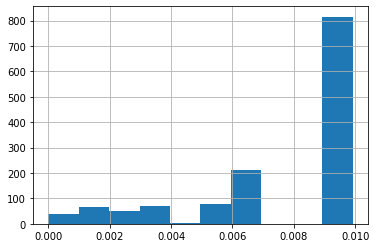

In [15]:
temp_PEA.loc[2000].hist()

In [11]:
PEA_csvs = sorted(glob.glob('PEA*.csv')) # list output PEA files
times = pd.DataFrame(temp_rho_dic['FPV_real_nogaps'].time.values, columns = ['time'])

labels = ['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m', '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
          '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m', 
          '37% without gaps', '41% without gaps', '43% without gaps',
          '46% without gaps', 'No FPV coverage']

for scen in range(3, len(PEA_csvs), 1):
    temp_PEA = pd.read_csv(PEA_csvs[scen]).iloc[:, 1:] # read csv for PEA
    name = labels[scen-3]
    
    temp_PEA[name] = temp_PEA.max(axis = 1)
    temp_PEA = temp_PEA[temp_PEA.columns[[-1]]]
    temp_PEA['time'] = times['time']
    
    if scen == 3:
        PEA_df = temp_PEA.copy()
    else:
        PEA_df = pd.merge(PEA_df, temp_PEA, on = 'time', how = "inner")
    
PEA_df.set_index('time', inplace = True)
PEA_df.head(2)

,41% FPV - 10% gaps 80x80m,43% FPV - 5% gaps 10x10m,41% FPV - 10% gaps 10x10m,41% FPV - 10% gaps 10x20m,41% FPV - 10% gaps 20x20m,37% FPV - 20% gaps 10x10m,37% without gaps,41% without gaps,43% without gaps,46% without gaps,No FPV coverage
time,,,,,,,,,,,
2022-09-09 00:00:00,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554
2022-09-09 06:00:00,0.526028,0.526450,0.526871,0.527853,0.526329,0.527031,0.524945,0.526007,0.526306,0.528436,0.521636


In [81]:
PEA_df.to_csv('PEA_df_01_02.csv')

In [12]:
summary_PEA_scen = PEA_df.resample('M').mean()
summary_PEA_scen = summary_PEA_scen.loc['2023-04-30':'2023-08-31'].T
summary_PEA_scen['average'] = summary_PEA_scen.mean(axis = 1)
summary_PEA_scen = pd.DataFrame(summary_PEA_scen['average'])
summary_PEA_scen

,average
41% FPV - 10% gaps 80x80m,9.565311
43% FPV - 5% gaps 10x10m,9.644629
41% FPV - 10% gaps 10x10m,9.582550
41% FPV - 10% gaps 10x20m,9.606003
41% FPV - 10% gaps 20x20m,9.582835
37% FPV - 20% gaps 10x10m,9.442267
37% without gaps,9.423574
41% without gaps,9.589754
43% without gaps,9.676794
46% without gaps,9.727134


In [34]:
summary_PEA_scen[:-1].describe()

,average
count,10.000000
mean,9.584085
std,0.093967
min,9.423574
25%,9.569621
50%,9.586294
75%,9.634972
max,9.727134


## Time series plot PEA

In [17]:
PEA_df.columns

Index(['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m',
       '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
       '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m',
       '37% without gaps', '41% without gaps', '43% without gaps',
       '46% without gaps', 'No FPV coverage'],
      dtype='object')

<ipython-input-18-bd4d475a9fdd>:49: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax[1].set_xticklabels(xlabels_new)


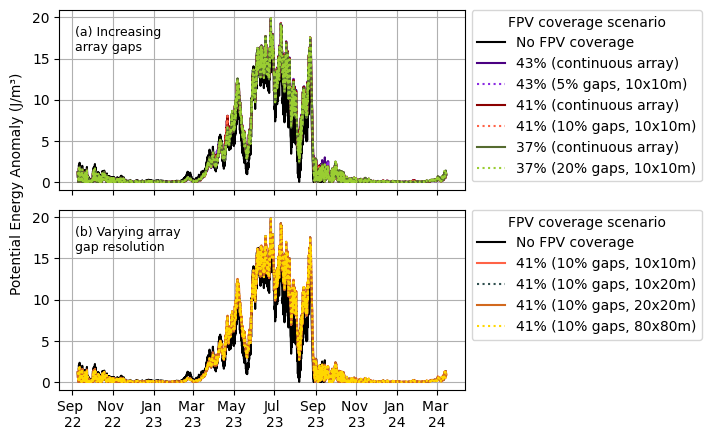

In [18]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = [7,4.5], sharex = True, sharey = True)
pal = sns.color_palette("tab20", 20)
linestyles = ['solid', 'solid', 'dotted','solid', 'dotted','solid', 'dotted']
colors_FPV02 = ['k', 'indigo', 'blueviolet', 'darkred', 'tomato', 'darkolivegreen', 'yellowgreen']
colors_FPV03 = ['k', 'tomato', 'darkslategray', 'chocolate', 'gold']

plot_number = 9
# scenarios = FPV_deltaWT_avdepth.columns

scenarios_FPV02 = ['No FPV coverage', '43% without gaps','43% FPV - 5% gaps 10x10m', 
                   '41% without gaps','41% FPV - 10% gaps 10x10m', 
                   '37% without gaps', '37% FPV - 20% gaps 10x10m']

labels_FPV02 = ['No FPV coverage', '43% (continuous array)', '43% (5% gaps, 10x10m)', 
                '41% (continuous array)', '41% (10% gaps, 10x10m)', 
                '37% (continuous array)', '37% (20% gaps, 10x10m)']

scenarios_FPV03 = ['No FPV coverage', '41% FPV - 10% gaps 10x10m','41% FPV - 10% gaps 10x20m', 
                   '41% FPV - 10% gaps 20x20m','41% FPV - 10% gaps 80x80m']

labels_FPV03 = ['No FPV coverage', '41% (10% gaps, 10x10m)', '41% (10% gaps, 10x20m)', 
                '41% (10% gaps, 20x20m)', '41% (10% gaps, 80x80m)']

PEA_df_plotFPV02 = PEA_df[scenarios_FPV02].copy()
for scen in range(len(PEA_df_plotFPV02.columns)):
    ax[0].plot(PEA_df_plotFPV02.index, PEA_df_plotFPV02[PEA_df_plotFPV02.columns[scen]], 
               color = colors_FPV02[scen], linestyle = linestyles[scen], label = (labels_FPV02[scen]))

ax[0].grid(True)
# ax[0].axhline(y = 0, color='r', linestyle='-', linewidth = 2)
ax[0].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[0].text(19240, 16, '(a) Increasing\narray gaps', color = 'k', fontsize = 9)

PEA_df_plotFPV03 = PEA_df[scenarios_FPV03].copy()
for scen in range(len(PEA_df_plotFPV03.columns)):
    ax[1].plot(PEA_df_plotFPV03.index, PEA_df_plotFPV03[PEA_df_plotFPV03.columns[scen]], 
               color = colors_FPV03[scen], linestyle = linestyles[scen], label = (labels_FPV03[scen]))

ax[1].grid(True)
# ax[1].axhline(y = 0, color='r', linestyle='-', linewidth = 2)
ax[1].legend(title = "FPV coverage scenario", ncol = 1, fontsize = 10, frameon = True, columnspacing = 1, 
             bbox_to_anchor=(1, 1.04))
ax[1].text(19240, 16, '(b) Varying array\ngap resolution', color = 'k', fontsize = 9)

xlabels = ['Sep 22', 'Nov 22', 'Jan 23', 'Mar 23', 'May 23', 'Jul 23', 'Sep 23', 'Nov 23', 'Jan 24', 'Mar 24']
xlabels_new = [re.sub("(.{4})", "\\1\n", label, 0, re.DOTALL) for label in xlabels]
ax[1].set_xticklabels(xlabels_new)

fig.text(-0.010, 0.58, u'Potential Energy Anomaly (J/m³)', 
         va='center', rotation='vertical')

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV02_03_underFPV_PEA_timeseries_noFPVincluded_contarray.jpeg', dpi=300, bbox_inches='tight')

plt.show();

In [15]:
path_figures

'C:/Users/midauarg/OneDrive - Lancaster University/PhD/Modelling - Lake CAB/results/RTRM/'

### Prepare data for boxplots

In [58]:
PEA_df.head(2)

,41% FPV - 10% gaps 80x80m,43% FPV - 5% gaps 10x10m,41% FPV - 10% gaps 10x10m,41% FPV - 10% gaps 10x20m,41% FPV - 10% gaps 20x20m,37% FPV - 20% gaps 10x10m,37% without gaps,41% without gaps,43% without gaps,46% without gaps,No FPV coverage
time,,,,,,,,,,,
2022-09-09 00:00:00,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554,1.166554
2022-09-09 06:00:00,0.526028,0.526450,0.526871,0.527853,0.526329,0.527031,0.524945,0.526007,0.526306,0.528436,0.521636


In [67]:
## DATAFRAME FOR CREATING BOXPLOTS
ndepths = 9 # number of model output time series per depth
scenarios = list(PEA_df.columns)

for scen in range(len(scenarios)):
    temporary = pd.DataFrame(PEA_df[scenarios[scen]].copy())

    temporary.reset_index(inplace = True)
    temporary.rename(columns = {temporary.columns[0]:'time', temporary.columns[1]:'PEA'}, inplace = True)
    temporary['scenario'] = scenarios[scen]
    # Join result to dataframe with control run output for comparison
    if (scen == 0):
        bp_PEA_comp = temporary.copy()
    else:
        bp_PEA_comp = pd.concat([bp_PEA_comp, temporary])

bp_PEA_comp['time'] = pd.to_datetime(bp_PEA_comp['time'])
bp_PEA_comp.set_index('time', inplace = True)
# # Creates columns with month
bp_PEA_comp['month'] = bp_PEA_comp.index.month
bp_PEA_comp['year'] = bp_PEA_comp.index.year
bp_PEA_comp['year'] = bp_PEA_comp['year'].apply(lambda x: str(x)[2:])
bp_PEA_comp['month_str'] = ((bp_PEA_comp['month'].apply(lambda x: calendar.month_abbr[x])) + 
                            (bp_PEA_comp['year']))
bp_PEA_comp.reset_index(drop = False, inplace = True)
bp_PEA_comp['season'] = bp_PEA_comp['time'].apply(season_of_date)
# bp_PEA_comp.reset_index(drop = True, inplace = True)
bp_PEA_comp.head(2)

,time,PEA,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,1.166554,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,0.526028,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer


In [80]:
bp_PEA_comp.scenario.unique()

array(['41% FPV - 10% gaps 80x80m', '43% FPV - 5% gaps 10x10m',
       '41% FPV - 10% gaps 10x10m', '41% FPV - 10% gaps 10x20m',
       '41% FPV - 10% gaps 20x20m', '37% FPV - 20% gaps 10x10m',
       '37% without gaps', '41% without gaps', '43% without gaps',
       '46% without gaps', 'No FPV coverage'], dtype=object)

In [81]:
# subset df for plots
bp_PEA_comp_FPV02 = bp_PEA_comp[(bp_PEA_comp['scenario'] == '43% without gaps') |
                                (bp_PEA_comp['scenario'] == '43% FPV - 5% gaps 10x10m') |
                                (bp_PEA_comp['scenario'] == '41% without gaps') |
                                (bp_PEA_comp['scenario'] == '41% FPV - 10% gaps 10x10m') |
                                (bp_PEA_comp['scenario'] == '37% without gaps') |
                                (bp_PEA_comp['scenario'] == '37% FPV - 20% gaps 10x10m')]

bp_PEA_comp_FPV03 = bp_PEA_comp[(bp_PEA_comp['scenario'] == '41% FPV - 10% gaps 10x10m') |
                                (bp_PEA_comp['scenario'] == '41% FPV - 10% gaps 10x20m') |
                                (bp_PEA_comp['scenario'] == '41% FPV - 10% gaps 20x20m') |
                                (bp_PEA_comp['scenario'] == '41% FPV - 10% gaps 80x80m')]

bp_PEA_comp_FPV03.head(2)

,time,PEA,scenario,month,year,month_str,season
0,2022-09-09 00:00:00,1.166554,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer
1,2022-09-09 06:00:00,0.526028,41% FPV - 10% gaps 80x80m,9,22,Sep22,summer


# Plots

In [100]:
teste = bp_PEA_comp_FPV03[bp_PEA_comp_FPV03['month'] == 9]
teste.scenario.unique()

array(['41% FPV - 10% gaps 80x80m', '41% FPV - 10% gaps 10x10m',
       '41% FPV - 10% gaps 10x20m', '41% FPV - 10% gaps 20x20m'],
      dtype=object)

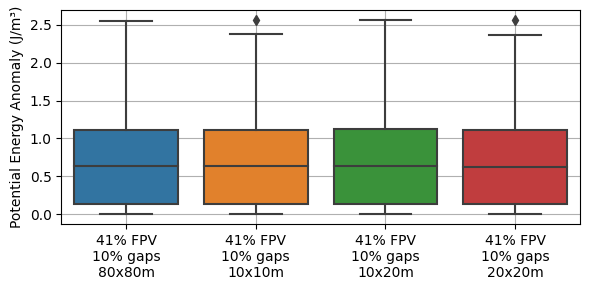

In [101]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [6,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "scenario", y = "PEA", 
            data = teste,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax)

ax.grid(True)

ax.yaxis.set_label_text(u'Potential Energy Anomaly (J/m³)', fontsize = 10)
ax.xaxis.set_label_text(u'')

ax.set_xticks([0,1,2,3],
              ['41% FPV\n10% gaps\n80x80m', '41% FPV\n10% gaps\n10x10m', 
               '41% FPV\n10% gaps\n10x20m', '41% FPV\n10% gaps\n20x20m'],
              fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV_scen_WT_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();

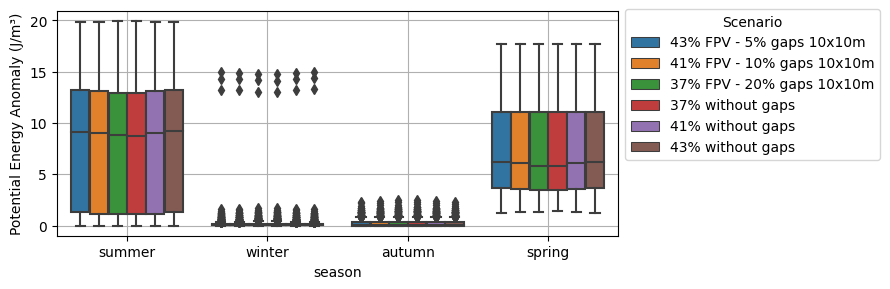

In [86]:
# Plot time series raw data for WT among scenarios
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = [9,3], sharex = True, sharey = True)
pal = sns.color_palette("tab10", 20)

sns.boxplot(x = "season", y = "PEA", 
            data = bp_PEA_comp_FPV02,
            width = 0.8, boxprops = {'zorder': 2}, palette = pal[0:8], ax = ax, hue = 'scenario')

ax.grid(True)

ax.legend(title = "Scenario", ncol = 1, fontsize = 10, 
               frameon = True, columnspacing = 1, bbox_to_anchor=(1, 1.04))

ax.yaxis.set_label_text(u'Potential Energy Anomaly (J/m³)', fontsize = 10)
# ax.xaxis.set_label_text(u'Depth (m)', fontsize = 10)

plt.subplots_adjust(wspace = 0, hspace = 0)

plt.tight_layout() # Para ajustar melhor os gráficos
plt.rcdefaults()
# plt.savefig(path_figures + 'FPV_scen_WT_bp_depth.jpeg', dpi=600, bbox_inches='tight')

plt.show();